  customer_id  age  income  spending_score  visits_per_month
0    CUST1000   56  120186              55                 9
1    CUST1001   69   49674              80                 1
2    CUST1002   46   61271              62                 8
3    CUST1003   32   88688              30                 6
4    CUST1004   60  126076              55                 6
customer_id         0
age                 0
income              0
spending_score      0
visits_per_month    0
dtype: int64


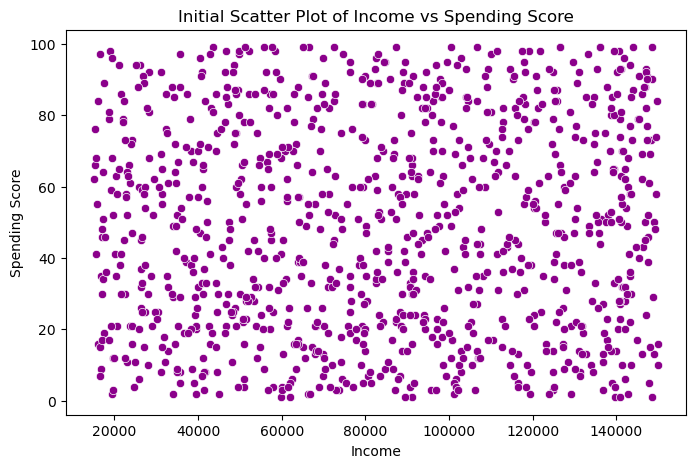

C:\Users\kgabo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\kgabo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\kgabo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\kgabo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

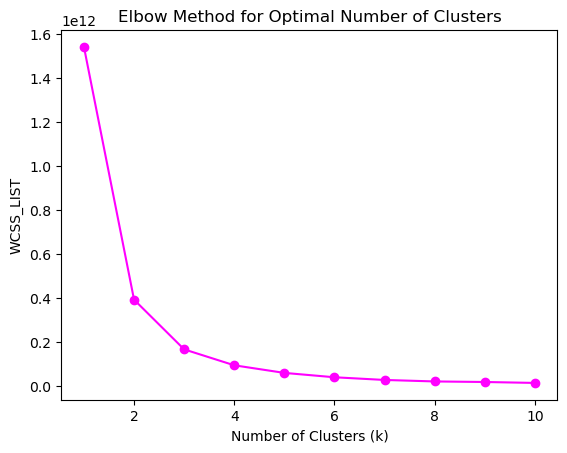

C:\Users\kgabo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


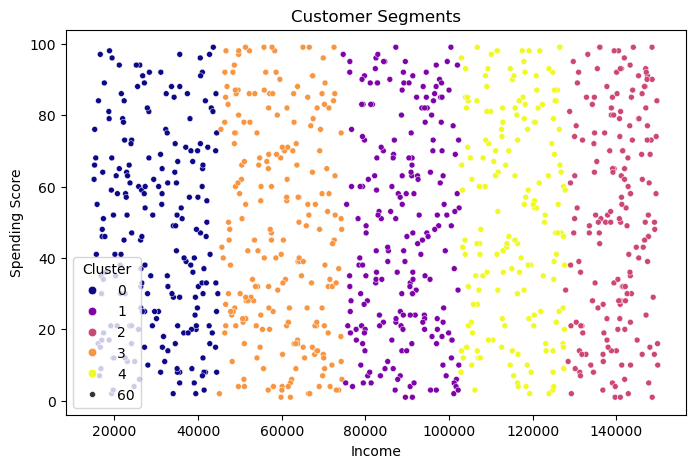

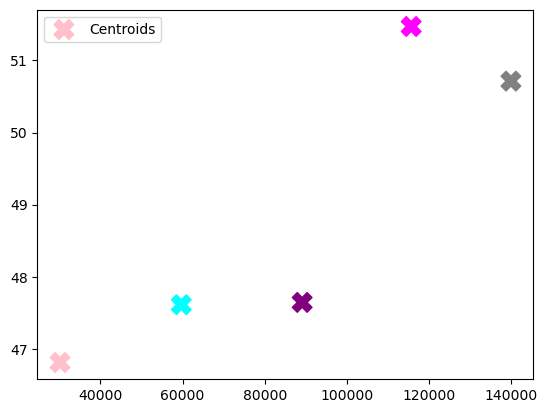

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import numpy as np

#1. Data Preparation
#load the dataset and display a few rows
df = pd.read_csv('customer_segmentation.csv', delimiter = ";")
print(df.head())

#check for any missing values within data
print(df.isnull().sum())

#Remove rows with null values
df = df.dropna()

#drop all columns except Income and Spending Score
df = df[["income", "spending_score"]]

#Create Scatter plot to examine patterns
plt.figure(figsize = (8,5))
sns.scatterplot(data = df, x = "income", y = "spending_score", c = "darkmagenta")
plt.title("Initial Scatter Plot of Income vs Spending Score")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.savefig("scatterpolt_incomevsspending.png")
plt.show()

#2. Cluster Analysis
#elbow method determines num of clusters
wcss_list = [] #initializing the list for values of WCSS

for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df)
    wcss_list.append(kmeans.inertia_)

#pLot the WCSS for values of k to determine clusters
plt.plot(range(1, 11), wcss_list, marker = "o", color = "magenta")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS_LIST")
plt.savefig("elbow_method.png")
plt.show()

#determine the optimal num of clusters
optimal_k = 5
kmeans = KMeans(n_clusters = optimal_k, random_state = 42)
clusters = kmeans.fit_predict(df)
df["Cluster"] = clusters

#plot the clusters using different colours
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = "income", y = "spending_score", hue = "Cluster", palette = "plasma", size = 60)
plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.savefig("scatterplot_clusters.png")
plt.show()

#mark the centroids on the clusters
colors = np.array(["pink","purple","gray","cyan","magenta"])
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s = 200, c = colors, marker = "X", label = "Centroids")
plt.legend()
plt.savefig("scatterplot_centroids.png")
plt.show()